# PCA Week 3


Dataset: Wine
Original data shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

--- PCA FROM SCRATCH ---
Explained variance ratio (all PCs): [0.362 0.192 0.111 0.071 0.066 0.049 0.042 0.027 0.022 0.019 0.017 0.013
 0.008]
Cumulative variance (first 2 PCs): 0.554

--- PCA VIA SCIKIT-LEARN ---
Explained variance ratio: [0.362 0.192]
Cumulative variance (first 2 PCs): 0.554

Sanity check passed: scratch implementation matches scikit-learn.

Saved figure: q1_wine_pca.png


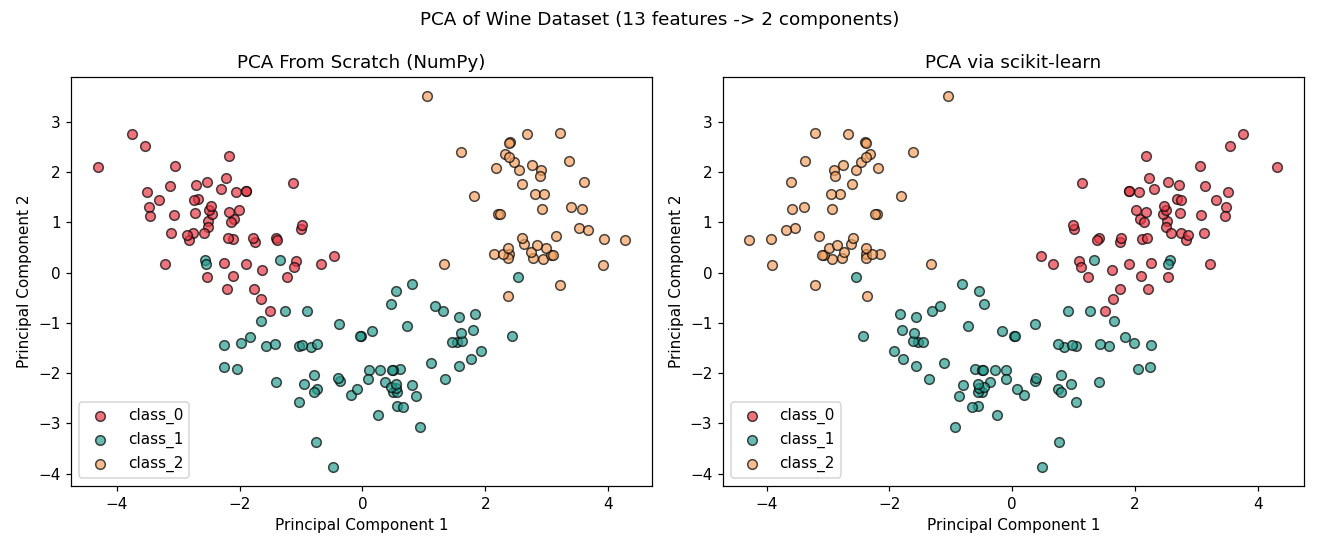

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print("Dataset: Wine")
print("Original data shape:", X.shape)
print("Feature names:", feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cov_matrix = np.cov(X_scaled.T)

eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

k = 2
projection_matrix = eigen_vectors[:, :k]
X_pca_scratch = X_scaled.dot(projection_matrix)

explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("\n--- PCA FROM SCRATCH ---")
print("Explained variance ratio (all PCs):", np.round(explained_variance_ratio, 3))
print("Cumulative variance (first 2 PCs):", np.round(np.sum(explained_variance_ratio[:2]), 3))

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)
print("\n--- PCA VIA SCIKIT-LEARN ---")
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (first 2 PCs):", np.round(np.sum(pca.explained_variance_ratio_), 3))

assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"
print("\nSanity check passed: scratch implementation matches scikit-learn.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch (NumPy)", "PCA via scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.7, edgecolor="k", s=40
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()

plt.suptitle("PCA of Wine Dataset (13 features -> 2 components)")
plt.tight_layout()
plt.savefig("q1_wine_pca.png", dpi=110)
print("\nSaved figure: q1_wine_pca.png")


In [1]:
import numpy as np
import pandas as pd
import io
from sklearn.datasets import load_wine, load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

results = []

def variance_captured(X, name, n_features_label):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    pca.fit(X_scaled)
    cum_var = np.sum(pca.explained_variance_ratio_)
    results.append({
        "Dataset": name,
        "Original Features": n_features_label,
        "Variance Captured by 2 PCs": f"{cum_var*100:.1f}%"
    })
    return cum_var

# Wine
wine = load_wine()
variance_captured(wine.data, "Wine", wine.data.shape[1])

# Breast Cancer
bc = load_breast_cancer()
variance_captured(bc.data, "Breast Cancer", bc.data.shape[1])

# Digits
digits = load_digits()
variance_captured(digits.data, "Digits", digits.data.shape[1])

# Messy synthetic customer dataset (mixed numeric + categorical, with missing values)
csv_data = """customer_id,age,income,spending_score,city
1,25,40000,60,Delhi
2,32,52000,45,Mumbai
3,,61000,30,Delhi
4,45,,20,Chennai
5,29,45000,70,Mumbai
6,52,58000,55,Delhi
7,38,,65,Chennai
8,,72000,25,Mumbai
9,41,49000,50,Delhi
10,27,39000,80,Chennai
"""
raw_df = pd.read_csv(io.StringIO(csv_data))
raw_df = raw_df.drop(columns=["customer_id"])  # non-informative identifier

numeric_cols = ["age", "income", "spending_score"]
categorical_cols = ["city"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])
X_clean = preprocessor.fit_transform(raw_df)
pca_messy = PCA(n_components=2)
pca_messy.fit(X_clean)
cum_var_messy = np.sum(pca_messy.explained_variance_ratio_)
results.append({
    "Dataset": "Messy Customer CSV (Sec. 6)",
    "Original Features": f"{raw_df.shape[1]} (mixed)",
    "Variance Captured by 2 PCs": f"{cum_var_messy*100:.1f}%"
})

results_df = pd.DataFrame(results)
print("PCA applied across multiple datasets (2 components each):\n")
print(results_df.to_string(index=False))


PCA applied across multiple datasets (2 components each):

                    Dataset Original Features Variance Captured by 2 PCs
                       Wine                13                      55.4%
              Breast Cancer                30                      63.2%
                     Digits                64                      21.6%
Messy Customer CSV (Sec. 6)         4 (mixed)                      78.4%


Explained variance ratio (3 PCs): [0.362 0.192 0.111]
Cumulative variance (first 3 PCs): 0.665

Saved figure: q3_wine_pca_3d.png


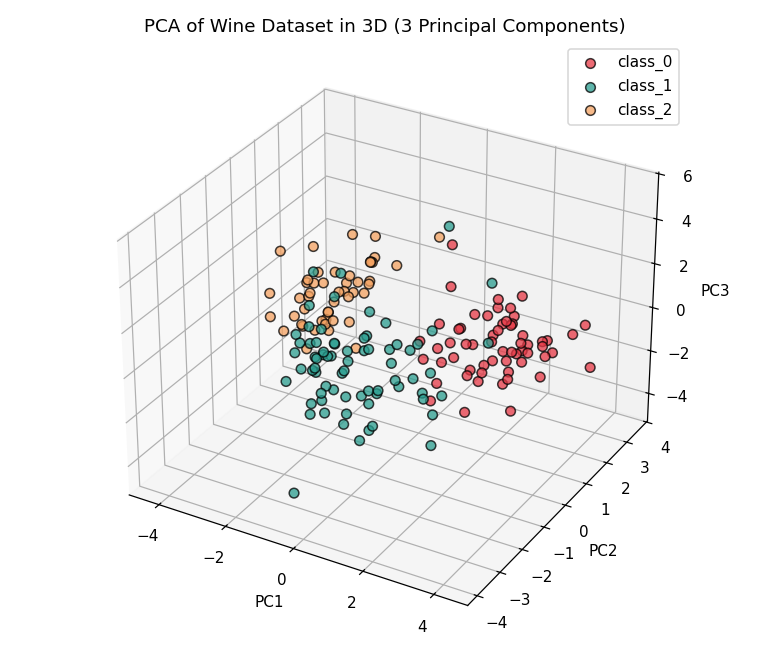

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

print("Explained variance ratio (3 PCs):", np.round(pca3.explained_variance_ratio_, 3))
print("Cumulative variance (first 3 PCs):", np.round(np.sum(pca3.explained_variance_ratio_), 3))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
colors = ["#e63946", "#2a9d8f", "#f4a261"]

for i, name in enumerate(target_names):
    ax.scatter(
        X_pca3[y == i, 0], X_pca3[y == i, 1], X_pca3[y == i, 2],
        label=name, color=colors[i], alpha=0.75, edgecolor="k", s=40
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA of Wine Dataset in 3D (3 Principal Components)")
ax.legend()
plt.tight_layout()
plt.savefig("q3_wine_pca_3d.png", dpi=110)
print("\nSaved figure: q3_wine_pca_3d.png")


In [2]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = wine.data
feature_names = wine.feature_names

print("Feature value ranges (raw, unscaled):")
for name, col in zip(feature_names, X.T):
    print(f"  {name:32s} min={col.min():10.2f}  max={col.max():10.2f}")

# PCA WITHOUT standardizing (raw data)
pca_raw = PCA(n_components=2)
pca_raw.fit(X)
print("\n--- PCA WITHOUT STANDARDIZATION (raw data) ---")
print("Explained variance ratio:", np.round(pca_raw.explained_variance_ratio_, 3))
print("Cumulative variance (2 PCs):", np.round(np.sum(pca_raw.explained_variance_ratio_), 3))
print("Top loadings of PC1 (by magnitude):")
loadings_raw = pca_raw.components_[0]
top_idx_raw = np.argsort(np.abs(loadings_raw))[::-1][:3]
for idx in top_idx_raw:
    print(f"  {feature_names[idx]:32s} weight={loadings_raw[idx]:.3f}")

# PCA WITH standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_scaled = PCA(n_components=2)
pca_scaled.fit(X_scaled)
print("\n--- PCA WITH STANDARDIZATION (scaled data) ---")
print("Explained variance ratio:", np.round(pca_scaled.explained_variance_ratio_, 3))
print("Cumulative variance (2 PCs):", np.round(np.sum(pca_scaled.explained_variance_ratio_), 3))
print("Top loadings of PC1 (by magnitude):")
loadings_scaled = pca_scaled.components_[0]
top_idx_scaled = np.argsort(np.abs(loadings_scaled))[::-1][:3]
for idx in top_idx_scaled:
    print(f"  {feature_names[idx]:32s} weight={loadings_scaled[idx]:.3f}")


Feature value ranges (raw, unscaled):
  alcohol                          min=     11.03  max=     14.83
  malic_acid                       min=      0.74  max=      5.80
  ash                              min=      1.36  max=      3.23
  alcalinity_of_ash                min=     10.60  max=     30.00
  magnesium                        min=     70.00  max=    162.00
  total_phenols                    min=      0.98  max=      3.88
  flavanoids                       min=      0.34  max=      5.08
  nonflavanoid_phenols             min=      0.13  max=      0.66
  proanthocyanins                  min=      0.41  max=      3.58
  color_intensity                  min=      1.28  max=     13.00
  hue                              min=      0.48  max=      1.71
  od280/od315_of_diluted_wines     min=      1.27  max=      4.00
  proline                          min=    278.00  max=   1680.00

--- PCA WITHOUT STANDARDIZATION (raw data) ---
Explained variance ratio: [0.998 0.002]
Cumulative varia

Digits data shape: (1797, 64) (1797 samples, 64 pixel features)

Minimum components needed to reach 90% cumulative variance: 31
Cumulative variance at 31 components: 0.9005
Cumulative variance at 2 components (for comparison): 0.2159

Saved figure: q5_digits_cumvar.png


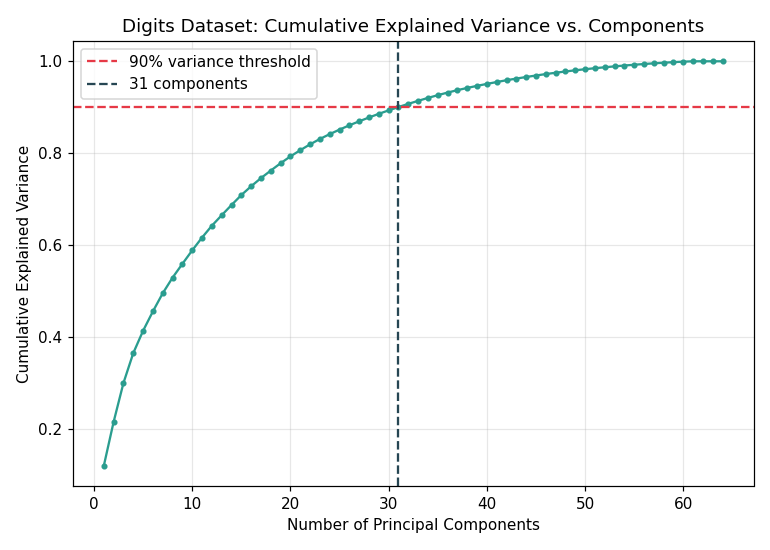

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data
print("Digits data shape:", X.shape, "(1797 samples, 64 pixel features)")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()  # keep all components
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Minimum number of components to reach >= 90% cumulative variance
min_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\nMinimum components needed to reach 90% cumulative variance: {min_components_90}")
print(f"Cumulative variance at {min_components_90} components: {cumulative_variance[min_components_90 - 1]:.4f}")
print(f"Cumulative variance at 2 components (for comparison): {cumulative_variance[1]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker=".", color="#2a9d8f")
plt.axhline(y=0.90, color="#e63946", linestyle="--", label="90% variance threshold")
plt.axvline(x=min_components_90, color="#264653", linestyle="--",
            label=f"{min_components_90} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Digits Dataset: Cumulative Explained Variance vs. Components")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("q5_digits_cumvar.png", dpi=110)
print("\nSaved figure: q5_digits_cumvar.png")


Raw dataset:
   customer_id  tenure_months  ...   contract_type  churned
0         C001           12.0  ...  Month-to-month        1
1         C002           48.0  ...        Two year        0
2         C003            NaN  ...        One year        0
3         C004            5.0  ...  Month-to-month        1
4         C005           60.0  ...        Two year        0
5         C006           24.0  ...        One year        0
6         C007            3.0  ...  Month-to-month        1
7         C008           36.0  ...             NaN        0
8         C009           18.0  ...  Month-to-month        1
9         C010            NaN  ...        One year        0
10        C011           52.0  ...        Two year        0
11        C012            8.0  ...  Month-to-month        1

[12 rows x 6 columns]

Missing values per column:
customer_id        0
tenure_months      2
monthly_charges    1
total_charges      1
contract_type      1
churned            0
dtype: int64

Shape after prep

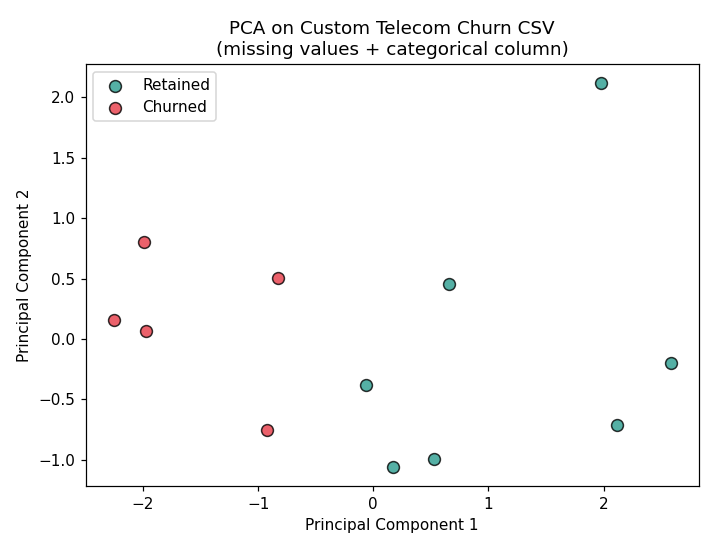

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# A synthetic "own dataset": telecom customer churn data
# Contains: missing numeric values, a categorical column, and an ID column
csv_data = """customer_id,tenure_months,monthly_charges,total_charges,contract_type,churned
C001,12,65.5,780.0,Month-to-month,1
C002,48,89.0,4272.0,Two year,0
C003,,54.2,,One year,0
C004,5,95.3,476.5,Month-to-month,1
C005,60,45.0,2700.0,Two year,0
C006,24,,1560.0,One year,0
C007,3,101.2,303.6,Month-to-month,1
C008,36,70.0,2520.0,,0
C009,18,88.5,1593.0,Month-to-month,1
C010,,60.0,1200.0,One year,0
C011,52,40.5,2106.0,Two year,0
C012,8,110.0,880.0,Month-to-month,1
"""
df = pd.read_csv(io.StringIO(csv_data))
print("Raw dataset:")
print(df)
print("\nMissing values per column:")
print(df.isna().sum())

y = df["churned"]
df_features = df.drop(columns=["customer_id", "churned"])  # drop ID + target

numeric_cols = ["tenure_months", "monthly_charges", "total_charges"]
categorical_cols = ["contract_type"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

X_clean = preprocessor.fit_transform(df_features)
print("\nShape after preprocessing (imputed + encoded + scaled):", X_clean.shape)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (2 PCs):", np.round(np.sum(pca.explained_variance_ratio_), 3))

plt.figure(figsize=(6.5, 5))
colors = {0: "#2a9d8f", 1: "#e63946"}
labels = {0: "Retained", 1: "Churned"}
for label in [0, 1]:
    mask = (y.values == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[label],
                label=labels[label], alpha=0.8, edgecolor="k", s=60)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Custom Telecom Churn CSV\n(missing values + categorical column)")
plt.legend()
plt.tight_layout()
plt.savefig("q6_custom_csv_pca.png", dpi=110)
print("\nSaved figure: q6_custom_csv_pca.png")
